<a href="https://colab.research.google.com/github/alfarisauliarahman/Alfaris-Aulia-Rahman_2411533006_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import library yang diperlukan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

plt.rcParams["figure.figsize"] = (7, 5)
sns.set_theme(style="whitegrid")


2. Load dan tampilkan Dataset

In [ ]:
dataset_url = 'https://raw.githubusercontent.com/alfarisauliarahman/Alfaris-Aulia-Rahman_2411533006_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data.csv'
data = pd.read_csv(dataset_url)
data.head()

print("Ukuran data:", data.shape)
print("\nJumlah nilai null per kolom:")
print(data.isnull().sum())
print("\nDistribusi target:")
print(data["diagnosis"].value_counts())

Ukuran data: (569, 6)

Jumlah nilai null per kolom:
mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

Distribusi target:
diagnosis
1    357
0    212
Name: count, dtype: int64


3. Visualisasikan dataset

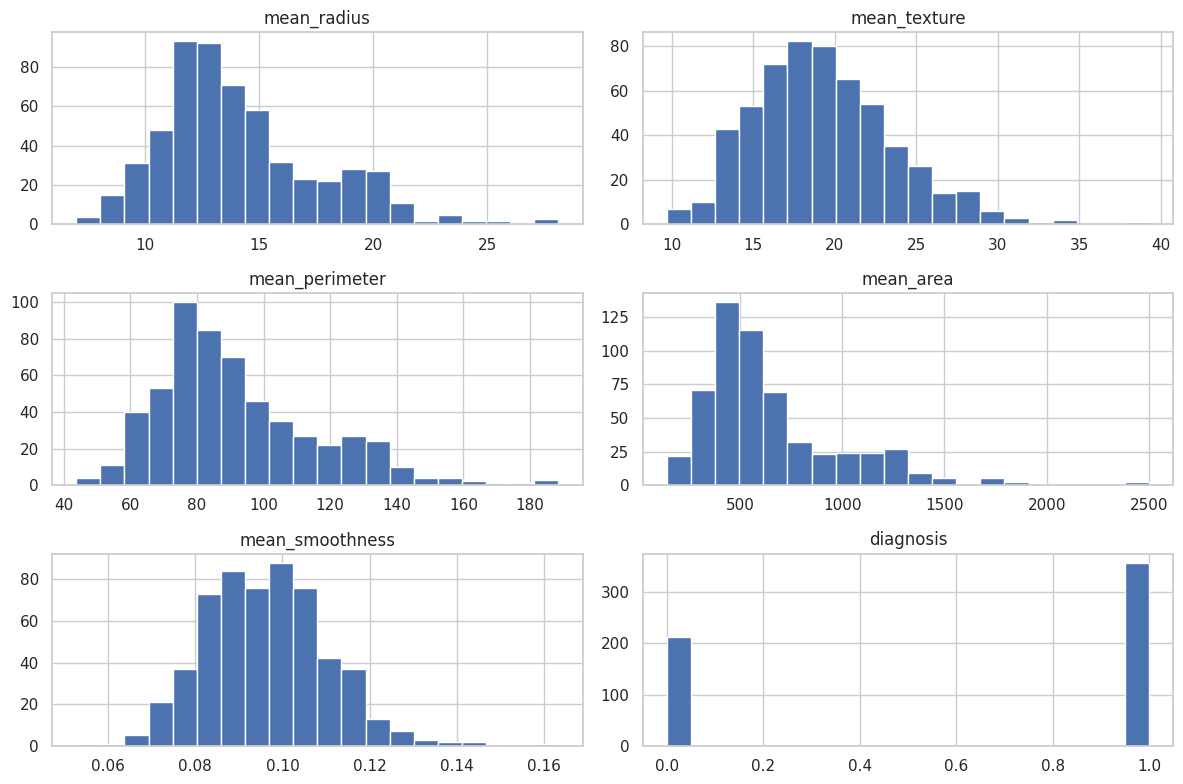

In [ ]:
data.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

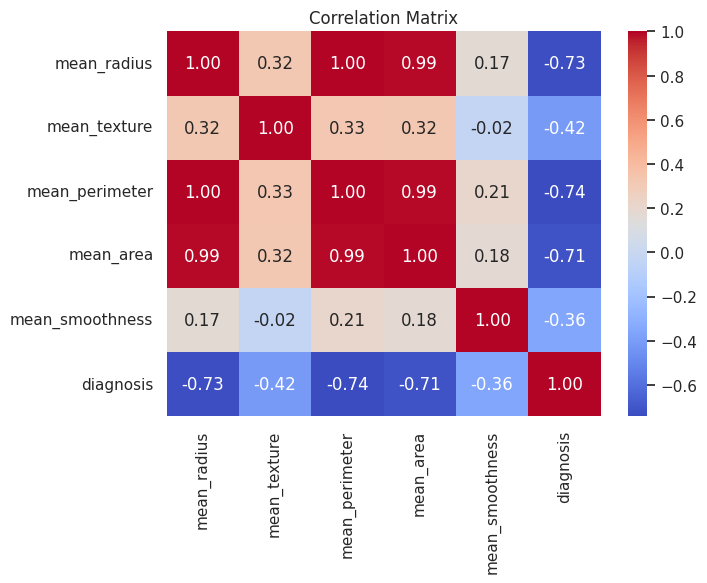

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

4. Pisahkan fitur dna target

In [ ]:
X = data.drop(columns=["diagnosis"])
y = data["diagnosis"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (569, 5)
Shape y: (569,)


5. Split data train dan test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=16,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (398, 5)
X_test : (171, 5)
y_train: (398,)
y_test : (171,)


6. Buat evaluasi untuk threshold

In [ ]:
def evaluate_thresholds(y_true, y_prob, thresholds, model_name):
    rows = []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        rows.append({
            "model": model_name,
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred),
            "recall": recall_score(y_true, y_pred),
            "f1_score": f1_score(y_true, y_pred),
            "auc": roc_auc_score(y_true, y_prob),
            "TN": cm[0, 0],
            "FP": cm[0, 1],
            "FN": cm[1, 0],
            "TP": cm[1, 1],
        })
    return pd.DataFrame(rows)


def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.show()


7. Model tanpa scaling

In [ ]:
model_no_scaling = LogisticRegression(random_state=16, max_iter=1000)
model_no_scaling.fit(X_train, y_train)

prob_no_scaling = model_no_scaling.predict_proba(X_test)[:, 1]
thresholds = [0.3, 0.5, 0.7]

results_no_scaling = evaluate_thresholds(
    y_test, prob_no_scaling, thresholds, "Tanpa Scaling"
)
results_no_scaling

,model,threshold,accuracy,precision,recall,f1_score,auc,TN,FP,FN,TP
0,Tanpa Scaling,0.3,0.918129,0.897436,0.981308,0.937500,0.965099,52,12,2,105
1,Tanpa Scaling,0.5,0.906433,0.917431,0.934579,0.925926,0.965099,55,9,7,100
2,Tanpa Scaling,0.7,0.888889,0.948980,0.869159,0.907317,0.965099,59,5,14,93


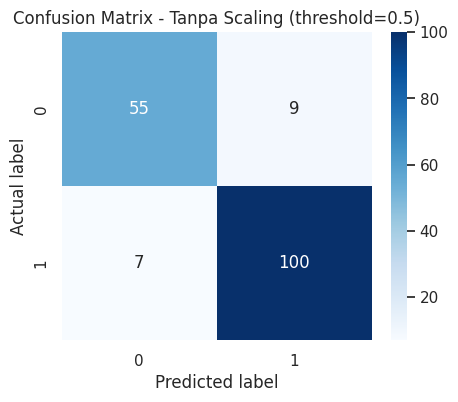

              precision    recall  f1-score   support

           0       0.89      0.86      0.87        64
           1       0.92      0.93      0.93       107

    accuracy                           0.91       171
   macro avg       0.90      0.90      0.90       171
weighted avg       0.91      0.91      0.91       171



In [ ]:
y_pred_no_scaling_05 = (prob_no_scaling >= 0.5).astype(int)

plot_conf_matrix(y_test, y_pred_no_scaling_05, "Confusion Matrix - Tanpa Scaling (threshold=0.5)")
print(classification_report(y_test, y_pred_no_scaling_05))

8. Model dengan menggunakan scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaling = LogisticRegression(random_state=16, max_iter=1000)
model_scaling.fit(X_train_scaled, y_train)

prob_scaling = model_scaling.predict_proba(X_test_scaled)[:, 1]

results_scaling = evaluate_thresholds(
    y_test, prob_scaling, thresholds, "Dengan Scaling"
)
results_scaling

,model,threshold,accuracy,precision,recall,f1_score,auc,TN,FP,FN,TP
0,Dengan Scaling,0.3,0.929825,0.905983,0.990654,0.946429,0.98087,53,11,1,106
1,Dengan Scaling,0.5,0.935673,0.936364,0.962617,0.949309,0.98087,57,7,4,103
2,Dengan Scaling,0.7,0.906433,0.959596,0.887850,0.922330,0.98087,60,4,12,95


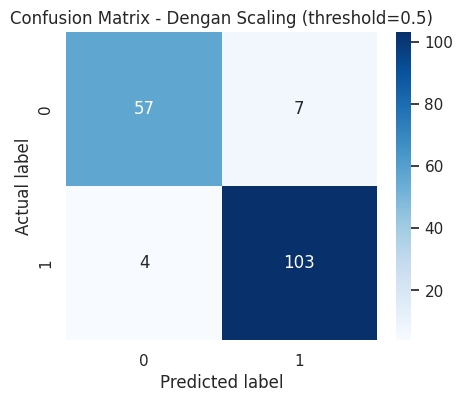

              precision    recall  f1-score   support

           0       0.93      0.89      0.91        64
           1       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



In [ ]:
y_pred_scaling_05 = (prob_scaling >= 0.5).astype(int)

plot_conf_matrix(y_test, y_pred_scaling_05, "Confusion Matrix - Dengan Scaling (threshold=0.5)")
print(classification_report(y_test, y_pred_scaling_05))

9. Hasil perbandingan dengan dan tanpa scaling

In [ ]:
comparison = pd.concat([results_no_scaling, results_scaling], ignore_index=True)
comparison = comparison[["model", "threshold", "accuracy", "precision", "recall", "f1_score", "auc", "TN", "FP", "FN", "TP"]]
comparison.sort_values(["model", "threshold"])

,model,threshold,accuracy,precision,recall,f1_score,auc,TN,FP,FN,TP
3,Dengan Scaling,0.3,0.929825,0.905983,0.990654,0.946429,0.980870,53,11,1,106
4,Dengan Scaling,0.5,0.935673,0.936364,0.962617,0.949309,0.980870,57,7,4,103
5,Dengan Scaling,0.7,0.906433,0.959596,0.887850,0.922330,0.980870,60,4,12,95
0,Tanpa Scaling,0.3,0.918129,0.897436,0.981308,0.937500,0.965099,52,12,2,105
1,Tanpa Scaling,0.5,0.906433,0.917431,0.934579,0.925926,0.965099,55,9,7,100
2,Tanpa Scaling,0.7,0.888889,0.948980,0.869159,0.907317,0.965099,59,5,14,93


ROC Curve

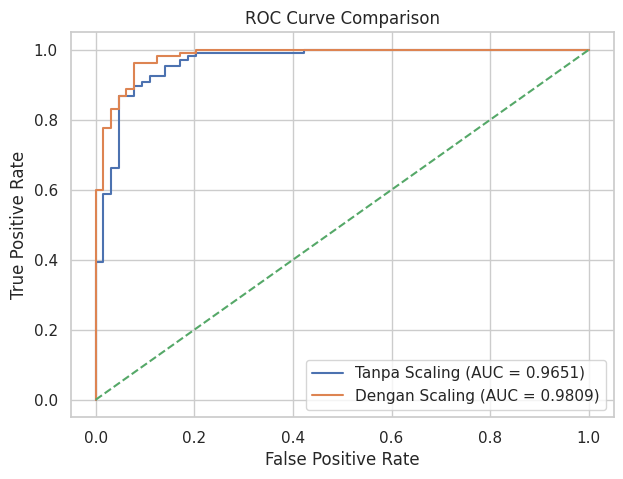

In [ ]:
fpr_no, tpr_no, _ = roc_curve(y_test, prob_no_scaling)
fpr_sc, tpr_sc, _ = roc_curve(y_test, prob_scaling)

auc_no = roc_auc_score(y_test, prob_no_scaling)
auc_sc = roc_auc_score(y_test, prob_scaling)

plt.figure(figsize=(7, 5))
plt.plot(fpr_no, tpr_no, label=f"Tanpa Scaling (AUC = {auc_no:.4f})")
plt.plot(fpr_sc, tpr_sc, label=f"Dengan Scaling (AUC = {auc_sc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()